|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">A deep understanding of AI language model mechanisms</a></h1>|
|-|:-:|
|<h2>Part 1:</h2>|<h1>Tokenizations and embeddings<h1>|
|<h2>Section:</h2>|<h1>Embedding spaces<h1>|
|<h2>Lecture:</h2>|<h1><b>CodeChallenge HELPER: Wikipedia vs. Twitter embeddings<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">udemy.com/course/dullms_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# svg figure format
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
from gensim.scripts.glove2word2vec import glove2word2vec
from gensim.models import KeyedVectors

# NOTE: If you get errors importing, run the following !pip... line,
# then restart your session (from Runtime menu) and comment out the pip line.
# !pip install gensim
import gensim.downloader as api


# Exercise 1: Download and inspect the models

In [ ]:
# download the wikipedia and twitter models
wiki = api.load('glove-wiki-gigaword-50')

In [3]:

# Path to your downloaded .txt file
glove_file = '/home/meysam/glove.2024.wikigiga.50d/wiki_giga_2024_50_MFT20_vectors_seed_123_alpha_0.75_eta_0.075_combined.txt'
# Output word2vec-format file (temporary)
w2v_file = 'glove-wiki-gigaword-50d.word2vec'

# Convert
# glove2word2vec(glove_file, w2v_file)

# Load the converted file
wiki = KeyedVectors.load_word2vec_format(w2v_file, binary=False)

In [ ]:
twit = api.load('glove-twitter-50')

In [4]:


# Path to your downloaded .txt file
glove_file = '/home/meysam/glove.twitter.27B/glove.twitter.27B.50d.txt'
# Output word2vec-format file (temporary)
w2v_file = 'glove.twitter.27B.50d.word2vec'

# Convert
# glove2word2vec(glove_file, w2v_file)

# Load the converted file
twit = KeyedVectors.load_word2vec_format(w2v_file, binary=False)

In [ ]:

# twit = api.load('glove-twitter-200')

In [5]:
dir(twit)

['__class__',
 '__contains__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_adapt_by_suffix',
 '_load_specials',
 '_log_evaluate_word_analogies',
 '_save_specials',
 '_smart_save',
 '_upconvert_old_d2vkv',
 '_upconvert_old_vocab',
 'add_lifecycle_event',
 'add_vector',
 'add_vectors',
 'allocate_vecattrs',
 'closer_than',
 'cosine_similarities',
 'distance',
 'distances',
 'doesnt_match',
 'evaluate_word_analogies',
 'evaluate_word_pairs',
 'expandos',
 'fill_norms',
 'get_index',
 'get_mean_vector',
 'get_normed_vectors',
 'get_vecattr',
 'get_vector',
 'has_index_for',
 

In [16]:
twit.vectors.shape

(1193514, 50)

In [15]:
# embedding matrix dimensions
print(f'Wikipedia model has {len(wiki.key_to_index.keys())} words and {wiki.vector_size} embedding dimensions.')
print(f'Twitter model has {len(twit.key_to_index.keys())} words and {twit.vector_size} embedding dimensions.')

Wikipedia model has 1291147 words and 50 embedding dimensions.
Twitter model has 1193514 words and 50 embedding dimensions.


In [ ]:
tidx = twit.key_to_index['table']

3764

# Exercise 2: Visualize the embeddings for one word

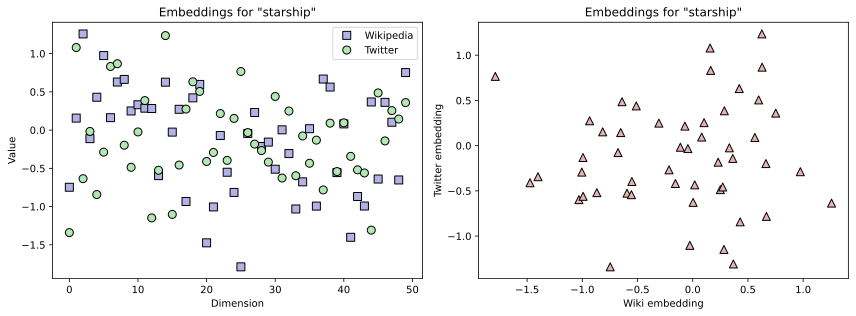

In [20]:
targetword = 'starship'
widx = wiki.key_to_index[targetword]
tidx = twit.key_to_index[targetword]

_,axs = plt.subplots(1,2,figsize=(12,4.5))
axs[0].plot(wiki.vectors[widx] ,'ks',markerfacecolor=[.7,.7,.9],markersize=8,label='Wikipedia')
axs[0].plot(twit.vectors[tidx],'ko',markerfacecolor=[.7,.9,.7],markersize=8,label='Twitter')
axs[0].set(xlabel='Dimension',ylabel='Value',title=f'Embeddings for "{targetword}"')
axs[0].legend()

axs[1].plot(wiki[targetword],twit[targetword],'k^',markerfacecolor=[.9,.7,.7],markersize=8)
axs[1].set(xlabel='Wiki embedding',ylabel='Twitter embedding',title=f'Embeddings for "{targetword}"')

plt.tight_layout()
plt.show()

# Exercise 3: Embeddings for word pairs within each model

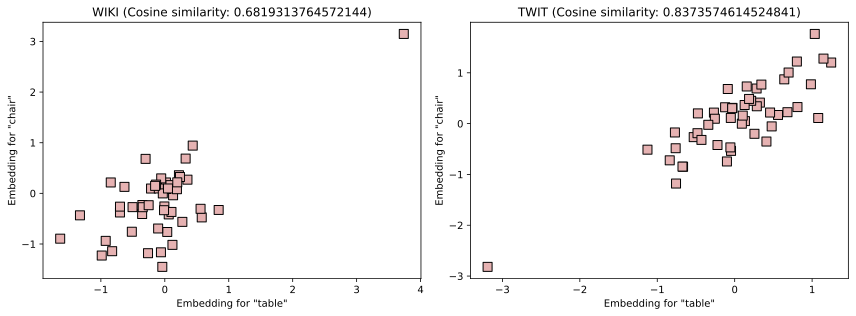

In [24]:
# word pair
word1 = 'table'
word2 = 'chair'

# scatter plot for wiki
wcossim = wiki.similarity(word1, word2)

_,axs = plt.subplots(1,2,figsize=(12,4.5))
axs[0].plot(wiki[word1],wiki[word2],'ks',markersize=9,markerfacecolor=[.9,.7,.7])
axs[0].set(xlabel=f'Embedding for "{word1}"',ylabel=f'Embedding for "{word2}"',
           title=f'WIKI (Cosine similarity: {wcossim})')


# scatter plot for twitter
wcossim = twit.similarity(word1, word2)

axs[1].plot(twit[word1],twit[word2],'ks',markersize=9,markerfacecolor=[.9,.7,.7])
axs[1].set(xlabel=f'Embedding for "{word1}"',ylabel=f'Embedding for "{word2}"',
           title=f'TWIT (Cosine similarity: {wcossim})')

plt.tight_layout()
plt.show()

# Exercise 4: Similar words within each model

In [30]:
print('10 words most similar to "battery" in wiki:')
ms = wiki.most_similar("battery",topn=10)
for m in ms:
    print(m[0], " ", m[1])

print('\nAnd in twitter:')

ms = twit.most_similar("battery",topn=10)
for m in ms:
    print(m[0], " ", m[1])


10 words most similar to "battery" in wiki:
batteries   0.8524048924446106
machine   0.725061297416687
rechargeable   0.721813440322876
gun   0.7111812233924866
storage   0.6921554207801819
equipped   0.689799964427948
unit   0.6891984939575195
automatic   0.6788833737373352
armor   0.6781104207038879
units   0.6760368347167969

And in twitter:
charger   0.8720738887786865
cell   0.8216446042060852
batteries   0.8167192935943604
laptop   0.8139174580574036
batt   0.8042665719985962
charging   0.7880637049674988
replacement   0.7854103446006775
adapter   0.7587377429008484
phone   0.7571932077407837
charge   0.749850869178772


In [29]:
m[0]

'units'

# Exercise 5: foxes and dogs

In [ ]:
text = 'The quick brown fox jumps over the lazy dog'

import re
words = re.split(' ', text.lower())


[0, 2609, 998, 2090, 12235, 74, 0, 16623, 3037]

In [38]:
# index sequence in the two embeddings
wiki_idx = [wiki.key_to_index[idx] for idx in words]
twit_idx = [twit.key_to_index[idx] for idx in words]

print(' Word |  Wiki | Twitter')
print('-'*23)
for o,w,t in zip(words,wiki_idx,twit_idx):
  print(f'{o:>5} | {w:>5} | {t:>5}')

 Word |  Wiki | Twitter
-----------------------
  the |     0 |    13
quick |  2609 |  2156
brown |   998 |  1871
  fox |  2090 |  4000
jumps | 12235 | 18014
 over |    74 |   254
  the |     0 |    13
 lazy | 16623 |  2222
  dog |  3037 |  1317


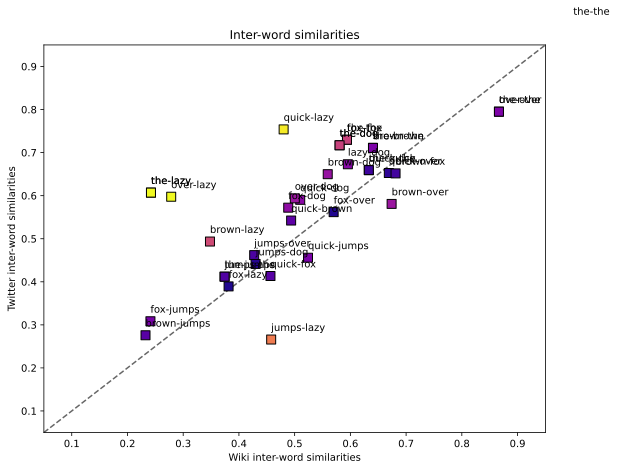

In [41]:
# get all unique inter-word similarities

plt.figure(figsize=(9,7))

# start range at 0 or 1?
for i in range(0,len(words)):
  for j in range(i+1,len(words)):

    # skip identity
    if i==j: continue

    # skip if doesn't exist (Inf)
    if np.isinf(wiki_idx[i] + wiki_idx[j]):
      continue

    # calculate the cosine similarities for the two embeddings
    cs_wiki = wiki.similarity(words[i], words[j])
    cs_twit = twit.similarity(words[i], words[j])

    # calculate the distance to the unity line
    v = np.array([float(cs_wiki), float(cs_twit)])
    u = np.array([1,1])
    dist = np.linalg.norm(v - (sum(v*u))/(np.linalg.norm(u)**2)*u)

    # draw the results at the coordinates
    plt.plot(cs_wiki,cs_twit,'ks',markersize=9,markerfacecolor=mpl.cm.plasma(dist*5))

    # and write the word pair
    plt.text(cs_wiki,cs_twit+.02,words[i]+"-"+words[j])



# plot the unity line
xylims = [.05,.95]
plt.plot(xylims,xylims,'--',color=[.4,.4,.4],zorder=-30)

# final adjustments
plt.gca().set(xlim=xylims,ylim=xylims,xlabel='Wiki inter-word similarities',
              ylabel='Twitter inter-word similarities',title='Inter-word similarities')
plt.show()